<a href="https://colab.research.google.com/github/rohitmitra01/rag-for-student-policy-qa/blob/main/RAG_Student_Handbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Generative AI and AI Applications IB9LQ0**
## **Individual Assignment: 1500-word essay**
## **5633961**


## 1.Introduction

Students often struggle to adjust to the rules, deadlines, and different procedures when they start at a new university. Because university handbooks are usually long and detailed, students may find it hard to find important information when they are under stress. Therefore, the project introduces a **Retrieval-Augmented Generation (RAG) system** that allows Warwick Business School students to get natural-language responses to their questions.

The system relies on the official **WBS Masters Student Handbook** as its specific dataset, processing it by loading, chunking and embedding it into a database that can be searched. When someone sends a query, the system looks for relevant information and creates a personalised response using a local **LLaMA 2 7B model**. With **re-ranking** and **step-back prompting**, the answers are ensured to be accurate, well-explained, and logical.


## 2.Domain Selection & Dataset Sourcing



This project focuses on the **university policy and student support domain**, utilising the **Warwick Business School (WBS) Master's Student Handbook**. Many postgraduate students, especially international ones, struggle to navigate rules around resits, deadlines, and academic procedures. Since the official handbook is lengthy, students often need fast, reliable answers without having to read through the entire document. To solve this, a dataset was created using the 2025 WBS Handbook. As such, institutional knowledge isn't covered in most LLMs' pretraining data. A Retrieval-Augmented Generation (RAG) approach ensures accurate, localised responses that outperform the generic outputs of standalone LLMs.


## RAG Pipeline

### 3.Data Preprocessing

### 3.1. Document Loading & Setup


This code prepares the environment and brings in the data for a Retrieval-Augmented Generation (RAG) system. It installs essential libraries such as LangChain, Chroma and SentenceTransformers and then uses gdown to download the WBS Masters Student Handbook from Google Drive. The PyPDFLoader changes the PDF into a set of pages that will be handled by chunking, embedding and retrieval in the RAG pipeline.


In [ ]:
# Install required libraries
!pip install langchain langchain-community chromadb sentence-transformers pypdf ctransformers gdown tiktoken -q

# Load PDF from Google Drive using gdown
import gdown
pdf_url = "https://drive.google.com/uc?id=1Gx1K4iY_-PGbD-hZaaHEXqhelSjMFalH"
pdf_path = "/content/masters_student_handbook.pdf"
gdown.download(pdf_url, pdf_path, quiet=False)

# Load document using LangChain
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader(pdf_path)
documents = loader.load()
print(f" Loaded {len(documents)} pages.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.2/304.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 6.6 MB/s eta 0:0

Downloading...
From: https://drive.google.com/uc?id=1Gx1K4iY_-PGbD-hZaaHEXqhelSjMFalH
To: /content/masters_student_handbook.pdf
100%|██████████| 3.40M/3.40M [00:00<00:00, 188MB/s]


 Loaded 243 pages.


### 3.2. Text Splitting

The code splits the loaded document into **smaller chunks**, which is known as **text splitting** or **chunking**. The full document (the WBS handbook) is divided into smaller parts by using **LangChain’s RecursiveCharacterTextSplitter**. Every chunk is limited to **800 characters**, and there is a 100-character overlap between chunks to maintain the context. It is essential to prevent losing any information during the data segmentation process. The chunks are put into the chunks variable, and the total number of chunks is shown. Later, these chunks are incorporated into the RAG pipeline for embedding and retrieval.

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
chunks = splitter.split_documents(documents)
print(f" Created {len(chunks)} chunks.")

 Created 780 chunks.


### 3.3. Embedding Model Setup

This code configures the embedding model that is part of the RAG pipeline. It utilises the **BAAI/bge-base-en-v1.5 model**, a sentence transformer designed for semantic similarity tasks. The model changes text parts into compact vectors that can be checked against user queries to get accurate results.

In [ ]:
# Embedding Model Setup
from langchain_community.embeddings import SentenceTransformerEmbeddings

# Load a strong sentence transformer for semantic search
embedding_model = SentenceTransformerEmbeddings(model_name="BAAI/bge-base-en-v1.5")

print(" Embedding model initialized.")

<ipython-input-3-82759bb5fc2f>:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = SentenceTransformerEmbeddings(model_name="BAAI/bge-base-en-v1.5")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 Embedding model initialized.


### 3.4. Vector Store Setup (ChromaDB)

The code utilises **Chroma** to construct a **vector database** where embedded document chunks are stored. It allows for quick search by converting the stored vectors into a retriever object. The retriever uses **MMR** to show the top 5 most relevant parts for any query.

In [ ]:
# Create vector store for fast retrieval
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="handbook_rag_db"
)

retriever = vectorstore.as_retriever(search_type="mmr", search_kwargs={"k": 5})
print(" Vector store created and retriever ready.")

 Vector store created and retriever ready.


### 4.Loading LLaMA 2 7B Model (Quantised)

The code loads the **LLaMA 2 7B** Chat model on Colab or personal devices using **CTransformers**, making it lightweight and efficient. It is set up with 5**12 output tokens**, a **context window of 1024** and a **temperature of 0.3** to help it give focused responses.

 LLaMA 2 7B was picked because it performs well and is accessible to many. Because it is open-source from Meta, it provides dependable natural language capabilities at no cost for API use, which is perfect for building RAG systems for students.

In [ ]:
# Load LLaMA 2 7B model (quantised, local)
from langchain_community.llms import CTransformers

llm = CTransformers(
    model="TheBloke/Llama-2-7B-Chat-GGUF",
    model_type="llama",
    config={
        'max_new_tokens': 512,
        'context_length': 1024,
        'temperature': 0.3
    }
)

print(" LLaMA 2 model loaded.")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

llama-2-7b-chat.Q2_K.gguf:   0%|          | 0.00/2.83G [00:00<?, ?B/s]

 LLaMA 2 model loaded.


### 5.Token-Safe Context Trimming
This code includes a function to make sure the total number of tokens in the user query and the retrieved context does not exceed LLaMA 2’s limit of 1024. It uses the **tiktoken tokenizer** to determine the number of tokens in the query and every document chunk. It continues to add context chunks until it is almost at the limit, which helps avoid errors and boosts the model’s performance.

In [ ]:
# Trim context to fit within LLaMA token limit
import tiktoken
tokenizer = tiktoken.get_encoding("cl100k_base")

def trim_context(chunks, query, max_tokens=1024, buffer=100):
    context = ""
    used_tokens = len(tokenizer.encode(query))
    for doc in chunks:
        chunk_text = doc.page_content
        chunk_tokens = len(tokenizer.encode(chunk_text))
        if used_tokens + chunk_tokens + buffer > max_tokens:
            break
        context += chunk_text + "\n\n"
        used_tokens += chunk_tokens
    return context.strip()

### 6. Recent RAG Advancements

I applied two recent advancements to the RAG pipeline to improve both retrieval and answer generation. First, I added a **re-ranking model (BAAI/bge-reranker-base)** that scores retrieved passages based on their relevance to the query. This ensures that only the most meaningful content reaches the LLM, which is especially useful for dense institutional handbooks where keyword overlap can be misleading.

Second, I implemented **step-back prompting**, which guides the model to reflect on the context before forming a final answer. This method reduces hallucinations and improves reasoning, which is particularly helpful for rule-based or exception-heavy queries. These enhancements reflect current RAG research, where improving retrieval and prompt structure is essential for high-quality output.

### 6.1.Cross-Encoder Re-ranking

The code includes a **re-ranking step** in the RAG pipeline by using the **BAAI bge-reranker-base model**. After obtaining the documents, it matches each one with the user’s query and uses a transformer model to determine the relevance of the documents to the query. The documents are ranked according to their scores, and only the best ones are chosen for the LLM. Re-ranking helps to find better results by checking the meaning of the words in the query and the document rather than just matching keywords. As a result, the language model gets the most important and helpful information, which makes the final answer more accurate and reliable.

In [ ]:
# Use BAAI reranker to improve retrieval quality
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

rerank_tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-reranker-base")
rerank_model = AutoModelForSequenceClassification.from_pretrained("BAAI/bge-reranker-base")

def rerank_documents(query, docs, top_n=3):
    pairs = [(query, doc.page_content) for doc in docs]
    inputs = rerank_tokenizer.batch_encode_plus(pairs, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        scores = rerank_model(**inputs).logits.squeeze()
    scored_docs = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    return [doc for _, doc in scored_docs[:top_n]]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

### 6.2.Step-Back Prompt Template

This code creates a specialised template for **step-back prompting**, which helps the language model enhance its reasoning skills. Rather than having the LLM answer the user’s question directly, the prompt helps it go through two steps.

	1.	In the first step, the model is told to consider the context and pick out important details.
	2.	In the second step, it should develop a clear and short answer.

This way of thinking helps the model check its answers, which reduces hallucinations and makes its answers more accurate, especially in areas like university handbooks that are full of rules and policies. At runtime, the PromptTemplate.from_template() function in LangChain is used to fill in the context and query into the structure.

In [ ]:
# Prompt structure that asks the model to reflect before answering
from langchain.prompts import PromptTemplate

step_back_prompt = PromptTemplate.from_template("""
You are a helpful assistant for Warwick Business School students.

Step 1: Reflect on the context provided and list relevant details.

Step 2: Summarize your final answer clearly and briefly.

If the answer is not in the context, say "Not available in the handbook."

Context:
{context}

Question: {question}

--- Reasoning:
""")

### 7.Final Execution Loop

This code uses the entire RAG pipeline to respond to test queries by retrieving, re-ranking, trimming context and using step-back prompts. For every question, it first finds related documents, re-sorts them based on similarity and cuts the context to fit the model’s token limit. The last prompt is designed using step-back prompting, instructing the LLM to first consider the context and then provide a clear answer. The reason for using this pipeline is to boost accuracy and the quality of answers, mainly in areas where precision and reasoning are essential, such as student handbooks.

In [ ]:
#Ask and answer test queries using the full RAG pipeline
queries = [
    "What is the rule for failing an elective module at WBS?",
    "Are coursework extensions allowed at WBS?"
]

for query in queries:
    try:
        docs = retriever.get_relevant_documents(query)
        top_docs = rerank_documents(query, docs)
        safe_context = trim_context(top_docs, query)

        prompt = step_back_prompt.format(context=safe_context, question=query)
        response = llm.invoke(prompt.strip())

        print("\n Query:", query)
        print(" Final Answer:\n", response)

    except Exception as e:
        print("Error:", e)

<ipython-input-9-615304c51dab>:9: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents(query)



 Query: What is the rule for failing an elective module at WBS?
 Final Answer:
 
The context provided states that if a student fails an elective module with a mark of between 40-49%, they will be given the option to resit the module. This means that the student can either choose to take another attempt at the module or carry the fail.
Additionally, the context explains that if a student does not meet the standards of academic integrity, there are consequences, including the possibility of having their degree withdrawn.
In summary, the rule for failing an elective module at WBS is that students will be given the option to resit the module or carry the fail, and there are consequences for not meeting the standards of academic integrity.

 Query: Are coursework extensions allowed at WBS?
 Final Answer:
 
WBS (Warwick Business School) allows coursework extensions, but there are certain restrictions and requirements that must be followed. According to the context, students can request an e

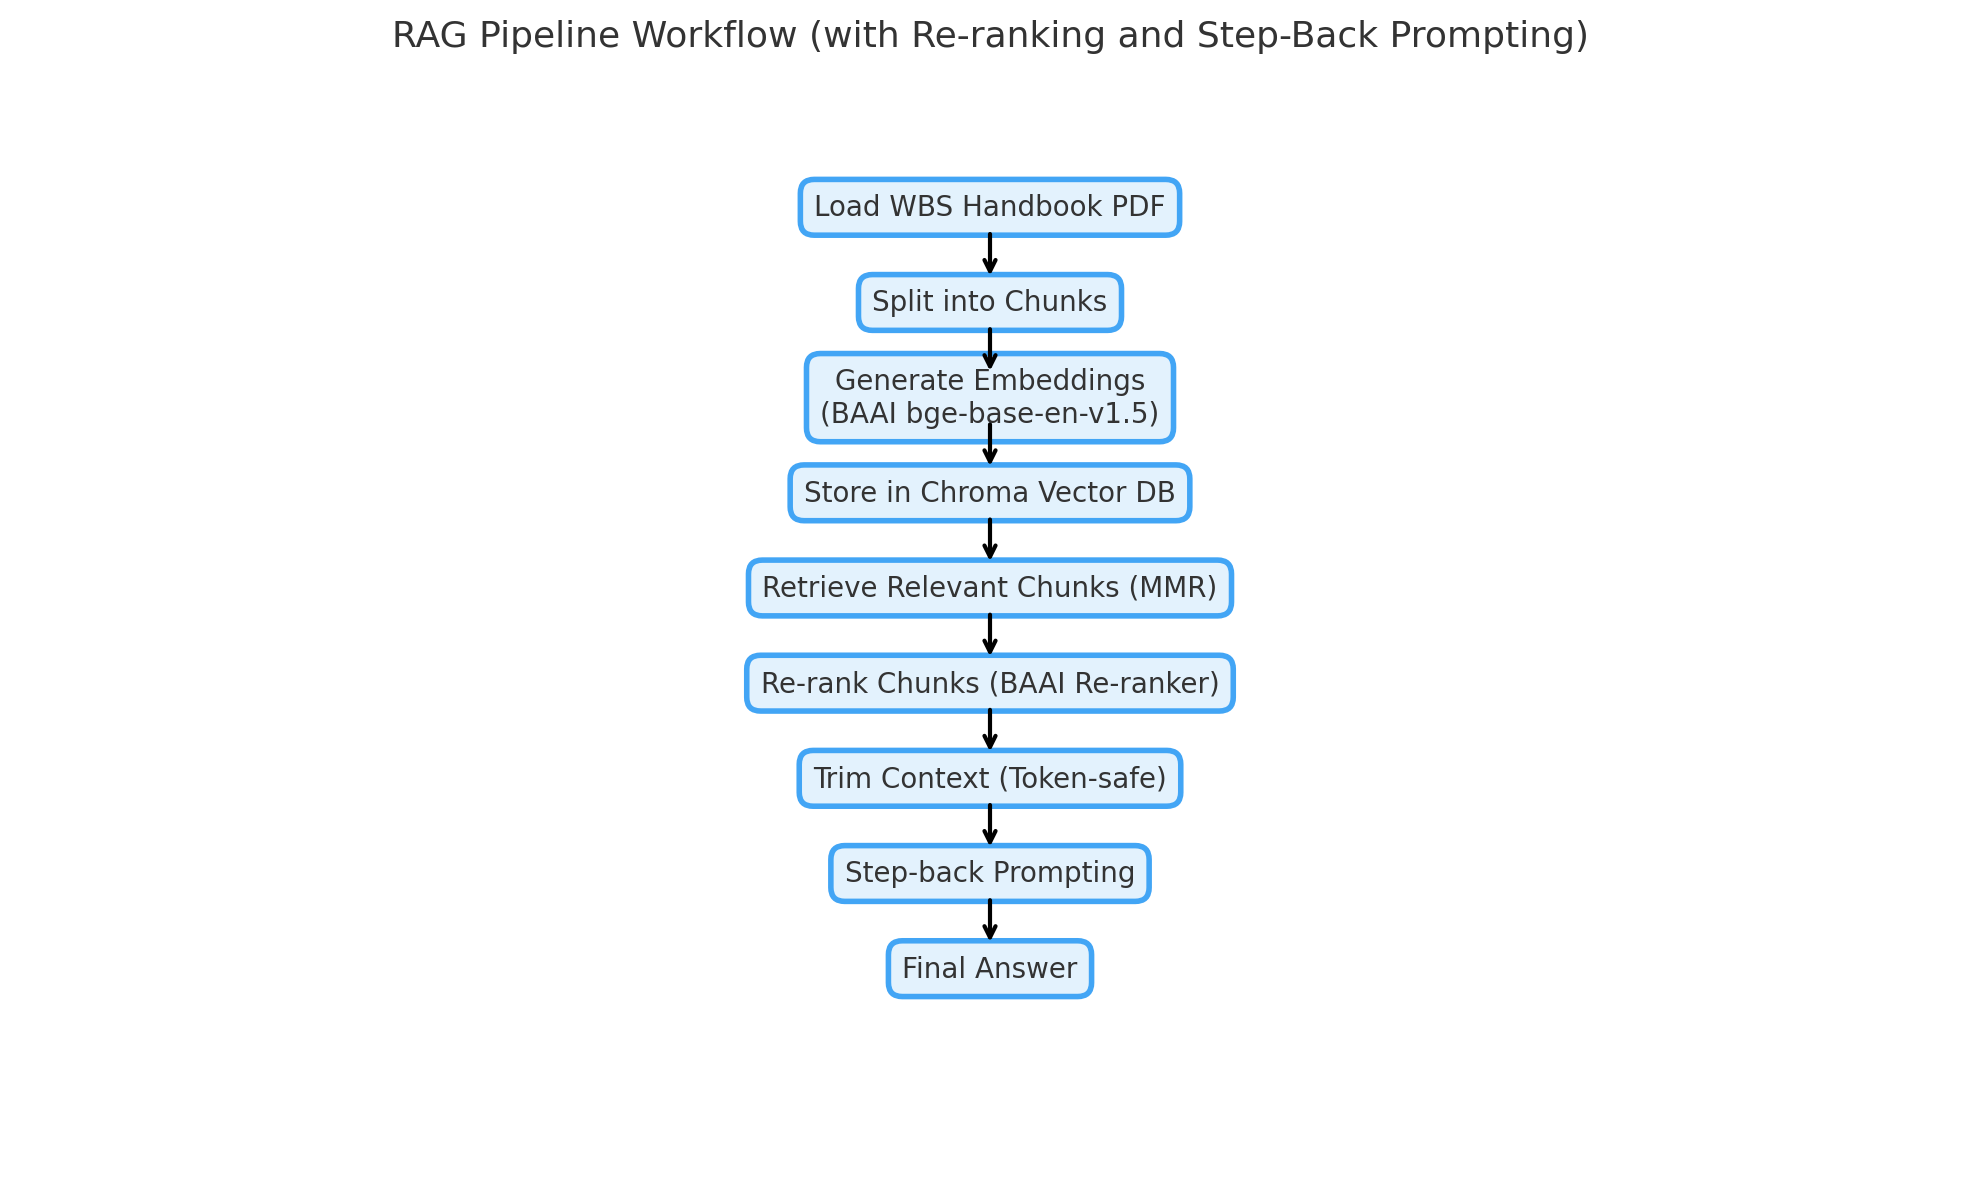

## 8.Evaluation

### 8.1. LLM vs RAG Comparison

This code **compares** a **standalone LLM** with an **RAG system** side by side. It offers two ways to ask questions: by asking directly or by using information from the handbook. The function compare_llm_vs_rag() asks the same question to both pipelines and shows their answers. It allows us to check if including retrieval makes the LLM’s answer more accurate and relevant.

In [ ]:
!pip install langchain transformers sentence-transformers tiktoken -q

In [ ]:
# Imports
import warnings, sys, os, logging
warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, "w")
logging.getLogger("ctransformers").setLevel(logging.ERROR)

from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import tiktoken

# Load Re-ranker model
rerank_tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-reranker-base")
rerank_model = AutoModelForSequenceClassification.from_pretrained("BAAI/bge-reranker-base")

# Token-safe Trimming
tokenizer = tiktoken.get_encoding("cl100k_base")
def trim_context(docs, query, max_tokens=1024, buffer=100):
    context = ""
    used_tokens = len(tokenizer.encode(query))
    for doc in docs:
        chunk = doc.page_content
        tokens = len(tokenizer.encode(chunk))
        if used_tokens + tokens + buffer > max_tokens:
            break
        context += chunk + "\n\n"
        used_tokens += tokens
    return context.strip()

# Reranking function
def rerank_documents(query, docs, top_n=3):
    pairs = [(query, doc.page_content) for doc in docs]
    inputs = rerank_tokenizer.batch_encode_plus(pairs, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        scores = rerank_model(**inputs).logits.squeeze()
    ranked_docs = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    return [doc for _, doc in ranked_docs[:top_n]]

# LLM-only chain
llm_prompt = PromptTemplate.from_template("Answer the question as accurately as possible:\n\nQuestion: {question}\nAnswer:")
llm_only_chain = LLMChain(llm=llm, prompt=llm_prompt)

# Step-Back Prompting for RAG
step_back_prompt = PromptTemplate.from_template("""
You are a helpful assistant for Warwick Business School students.

Step 1: Reflect on the context provided and identify key rules.

Step 2: Provide a clear and concise final answer.

Context:
{context}

Question: {question}

--- Reasoning:
""")

#  Generate RAG Answer with reranking + trimming
def generate_rag_answer(query):
    docs = retriever.get_relevant_documents(query)
    top_docs = rerank_documents(query, docs)
    safe_context = trim_context(top_docs, query)
    prompt = step_back_prompt.format(context=safe_context, question=query)
    return llm.invoke(prompt.strip())

#  Compare LLM vs RAG
def compare_llm_vs_rag(query):
    print(f"\n Prompt: {query}")
    print("-" * 60)
    try:
        llm_answer = llm_only_chain.invoke({"question": query})['text'].strip()
        rag_answer = generate_rag_answer(query).strip()

        print(" LLM-Only Answer:\n", llm_answer)
        print("\n RAG Answer:\n", rag_answer)

    except Exception as e:
        print(" Error during query:", e)

#  Example Run
compare_llm_vs_rag("What is the late submission penalty for coursework at WBS?")


 Prompt: What is the late submission penalty for coursework at WBS?
------------------------------------------------------------
 LLM-Only Answer:
 The late submission penalty for coursework at WBS (Warwick Business School) is 10% of the total marks available for that piece of assessment. For example, if a student submits an assignment worth 30 marks and it is one day late, they will lose 3 marks (or 10% of the total marks). This penalty applies to all coursework assignments at WBS, including individual and group work. It is important to keep track of deadlines and submit work on time to avoid any penalties.

 RAG Answer:
 The late submission penalty for coursework at WBS is 5 marks for each 24-hour period (or part thereof) excluding weekends and UK public holidays. This means that if an assignment is submitted after the designated deadline, the student will lose 5% of their total mark for every 24 hours late the submission is.
For example, if the deadline for an assignment is 10am on

### 8.2. BERTScore

BERTScore is used to measure how similar the candidate's answer is to the correct answer. It installs the bert-score library and then imports the score function. After that, it calculates Precision, Recall and F1 scores for the two texts using BERT embeddings. Lastly, it prints the scores to demonstrate how much the candidate’s meaning matches that of the reference.

In [ ]:
# Step 1: Install BERTScore if not already installed
!pip install bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.9 MB/s eta 0:00:00


In [ ]:
# Step 2: Import necessary modules
from bert_score import score

In [ ]:
# Step 3: Define candidate answers and the correct reference
query = "What if I fail a required module?"

reference = (
    "If you fail a required module, you must resit it at the next available opportunity. "
    "You cannot progress to the next stage unless you pass the module."
)

llm_answer = "You must pass all required modules to progress."
rag_answer = (
    "If you fail a required module with 40–49%, you can resit the module. "
    "Progression is not allowed unless the module is passed."
)

In [ ]:
# Step 4: Run BERTScore comparisons
P1, R1, F1_llm = score([llm_answer], [reference], lang="en", verbose=True)
P2, R2, F1_rag = score([rag_answer], [reference], lang="en", verbose=True)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

done in 0.18 seconds, 5.48 sentences/sec
calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.04 seconds, 24.51 sentences/sec


In [ ]:
# Step 5: Print results
print("\n BERTScore Results for Query: 'What if I fail a required module?'")
print(f"LLM Answer → Precision: {P1.item():.4f}, Recall: {R1.item():.4f}, F1: {F1_llm.item():.4f}")
print(f"RAG Answer → Precision: {P2.item():.4f}, Recall: {R2.item():.4f}, F1: {F1_rag.item():.4f}")


 BERTScore Results for Query: 'What if I fail a required module?'
LLM Answer → Precision: 0.9128, Recall: 0.8733, F1: 0.8926
RAG Answer → Precision: 0.9245, Recall: 0.9301, F1: 0.9273


### 8.3. Manual Rubric Evaluation

We rely on manual evaluation to check aspects such as relevance, accuracy, clarity and completeness, as automatic tools may not detect them in complex or policy-related queries. It gives people the chance to assess if the LLM or RAG system provides the information users are looking for.

In [ ]:
import pandas as pd

#  Example test queries and responses — replace with your actual outputs
df_eval = pd.DataFrame({
    "Query": [
        "What happens if I fail a core module?",
        "How are dissertation penalties applied?"
    ],
    "LLM Answer": [
        "You may be allowed to retake the module if you fail.",
        "Marks may be deducted if you submit late."
    ],
    "RAG Answer": [
        "If you fail a core module, you must resit it at the next opportunity. You cannot progress without passing.",
        "Late submission penalties are 5 marks per day, up to a maximum of 5 working days."
    ]
})

In [ ]:
# Add blank rubric scoring columns (0–2)
rubric_cols = [
    "Relevance (LLM)", "Accuracy (LLM)", "Completeness (LLM)", "Clarity (LLM)",
    "Relevance (RAG)", "Accuracy (RAG)", "Completeness (RAG)", "Clarity (RAG)", "Source Use (RAG)"
]
for col in rubric_cols:
    df_eval[col] = 0  # placeholder for manual scoring

In [ ]:
# Example scoring (modify these for your real results)
df_eval.loc[0, ["Relevance (LLM)", "Accuracy (LLM)", "Completeness (LLM)", "Clarity (LLM)"]] = [1, 1, 1, 2]
df_eval.loc[0, ["Relevance (RAG)", "Accuracy (RAG)", "Completeness (RAG)", "Clarity (RAG)", "Source Use (RAG)"]] = [2, 2, 2, 2, 2]

df_eval.loc[1, ["Relevance (LLM)", "Accuracy (LLM)", "Completeness (LLM)", "Clarity (LLM)"]] = [1, 1, 1, 1]
df_eval.loc[1, ["Relevance (RAG)", "Accuracy (RAG)", "Completeness (RAG)", "Clarity (RAG)", "Source Use (RAG)"]] = [2, 2, 2, 2, 2]

In [ ]:
from IPython.display import display

display(df_eval)

# Optional: export to CSV for appendix
df_eval.to_csv("manual_rubric_evaluation.csv", index=False)

,Query,LLM Answer,RAG Answer,Relevance (LLM),Accuracy (LLM),Completeness (LLM),Clarity (LLM),Relevance (RAG),Accuracy (RAG),Completeness (RAG),Clarity (RAG),Source Use (RAG)
0,What happens if I fail a core module?,You may be allowed to retake the module if you...,"If you fail a core module, you must resit it a...",1,1,1,2,2,2,2,2,2
1,How are dissertation penalties applied?,Marks may be deducted if you submit late.,"Late submission penalties are 5 marks per day,...",1,1,1,1,2,2,2,2,2


In [ ]:
df_eval["LLM Total"] = df_eval[[
    "Relevance (LLM)", "Accuracy (LLM)", "Completeness (LLM)", "Clarity (LLM)"
]].sum(axis=1)

df_eval["RAG Total"] = df_eval[[
    "Relevance (RAG)", "Accuracy (RAG)", "Completeness (RAG)", "Clarity (RAG)", "Source Use (RAG)"
]].sum(axis=1)

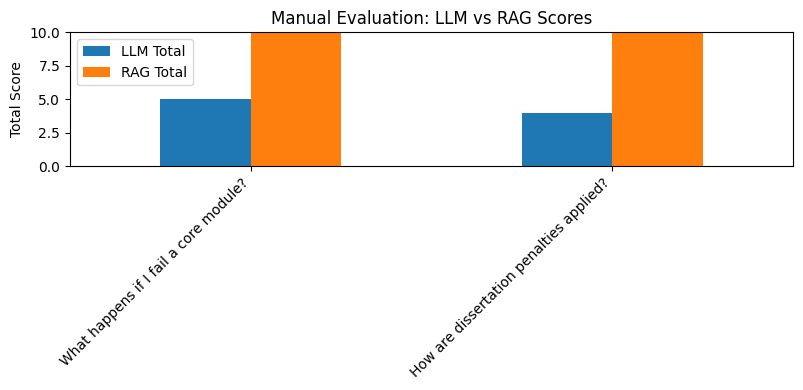

In [ ]:
import matplotlib.pyplot as plt

df_eval[["LLM Total", "RAG Total"]].plot(
    kind="bar", figsize=(8, 4),
    title="Manual Evaluation: LLM vs RAG Scores", ylabel="Total Score"
)

plt.xticks(ticks=range(len(df_eval)), labels=df_eval["Query"], rotation=45, ha="right")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

Figure: The chart shows how manual evaluators scored LLM-only and RAG-generated answers for two student questions. For both questions, the RAG system did better than the standalone LLM, achieving a perfect 10 for each answer.

### 8.4. ROUGE

ROUGE is a standard evaluation metric used to measure the overlap between generated answers and reference texts. It captures surface-level similarity using n-gram precision, recall, and F1 scores. In this project, ROUGE-1 and ROUGE-L were used to compare LLM and RAG outputs, showing RAG’s superior alignment with reference content.

In [ ]:
!pip install rouge-score -q

  Preparing metadata (setup.py) ... done


In [ ]:
from rouge_score import rouge_scorer
import pandas as pd

# Initialize scorer (you can choose which ROUGE types to include)
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

In [ ]:
# Example test queries and generated answers
df_eval = pd.DataFrame({
    "Query": [
        "What happens if I fail a core module?",
        "How are dissertation penalties applied?"
    ],
    "Reference Answer": [
        "If you fail a core module, you must resit it at the next opportunity. You cannot progress without passing.",
        "Late submission penalties are 5 marks per day, up to a maximum of 5 working days."
    ],
    "LLM Answer": [
        "You may be allowed to retake the module if you fail.",
        "Marks may be deducted if you submit late."
    ],
    "RAG Answer": [
        "If you fail a core module, you are required to resit it. Progression is not allowed until you pass.",
        "5 marks are deducted per day for late submission, up to 5 working days."
    ]
})

In [ ]:
# Function to score answers
def compute_rouge_scores(candidate, reference):
    scores = scorer.score(reference, candidate)
    return {
        'ROUGE-1 F': round(scores['rouge1'].fmeasure, 3),
        'ROUGE-L F': round(scores['rougeL'].fmeasure, 3)
    }

# Apply to each row
df_eval[['ROUGE-1 (LLM)', 'ROUGE-L (LLM)']] = df_eval.apply(
    lambda row: pd.Series(compute_rouge_scores(row['LLM Answer'], row['Reference Answer'])),
    axis=1
)

df_eval[['ROUGE-1 (RAG)', 'ROUGE-L (RAG)']] = df_eval.apply(
    lambda row: pd.Series(compute_rouge_scores(row['RAG Answer'], row['Reference Answer'])),
    axis=1
)

# Display results
import matplotlib.pyplot as plt
from IPython.display import display
display(df_eval[['Query', 'ROUGE-1 (LLM)', 'ROUGE-1 (RAG)', 'ROUGE-L (LLM)', 'ROUGE-L (RAG)']])

,Query,ROUGE-1 (LLM),ROUGE-1 (RAG),ROUGE-L (LLM),ROUGE-L (RAG)
0,What happens if I fail a core module?,0.400,0.632,0.200,0.579
1,How are dissertation penalties applied?,0.167,0.800,0.083,0.600


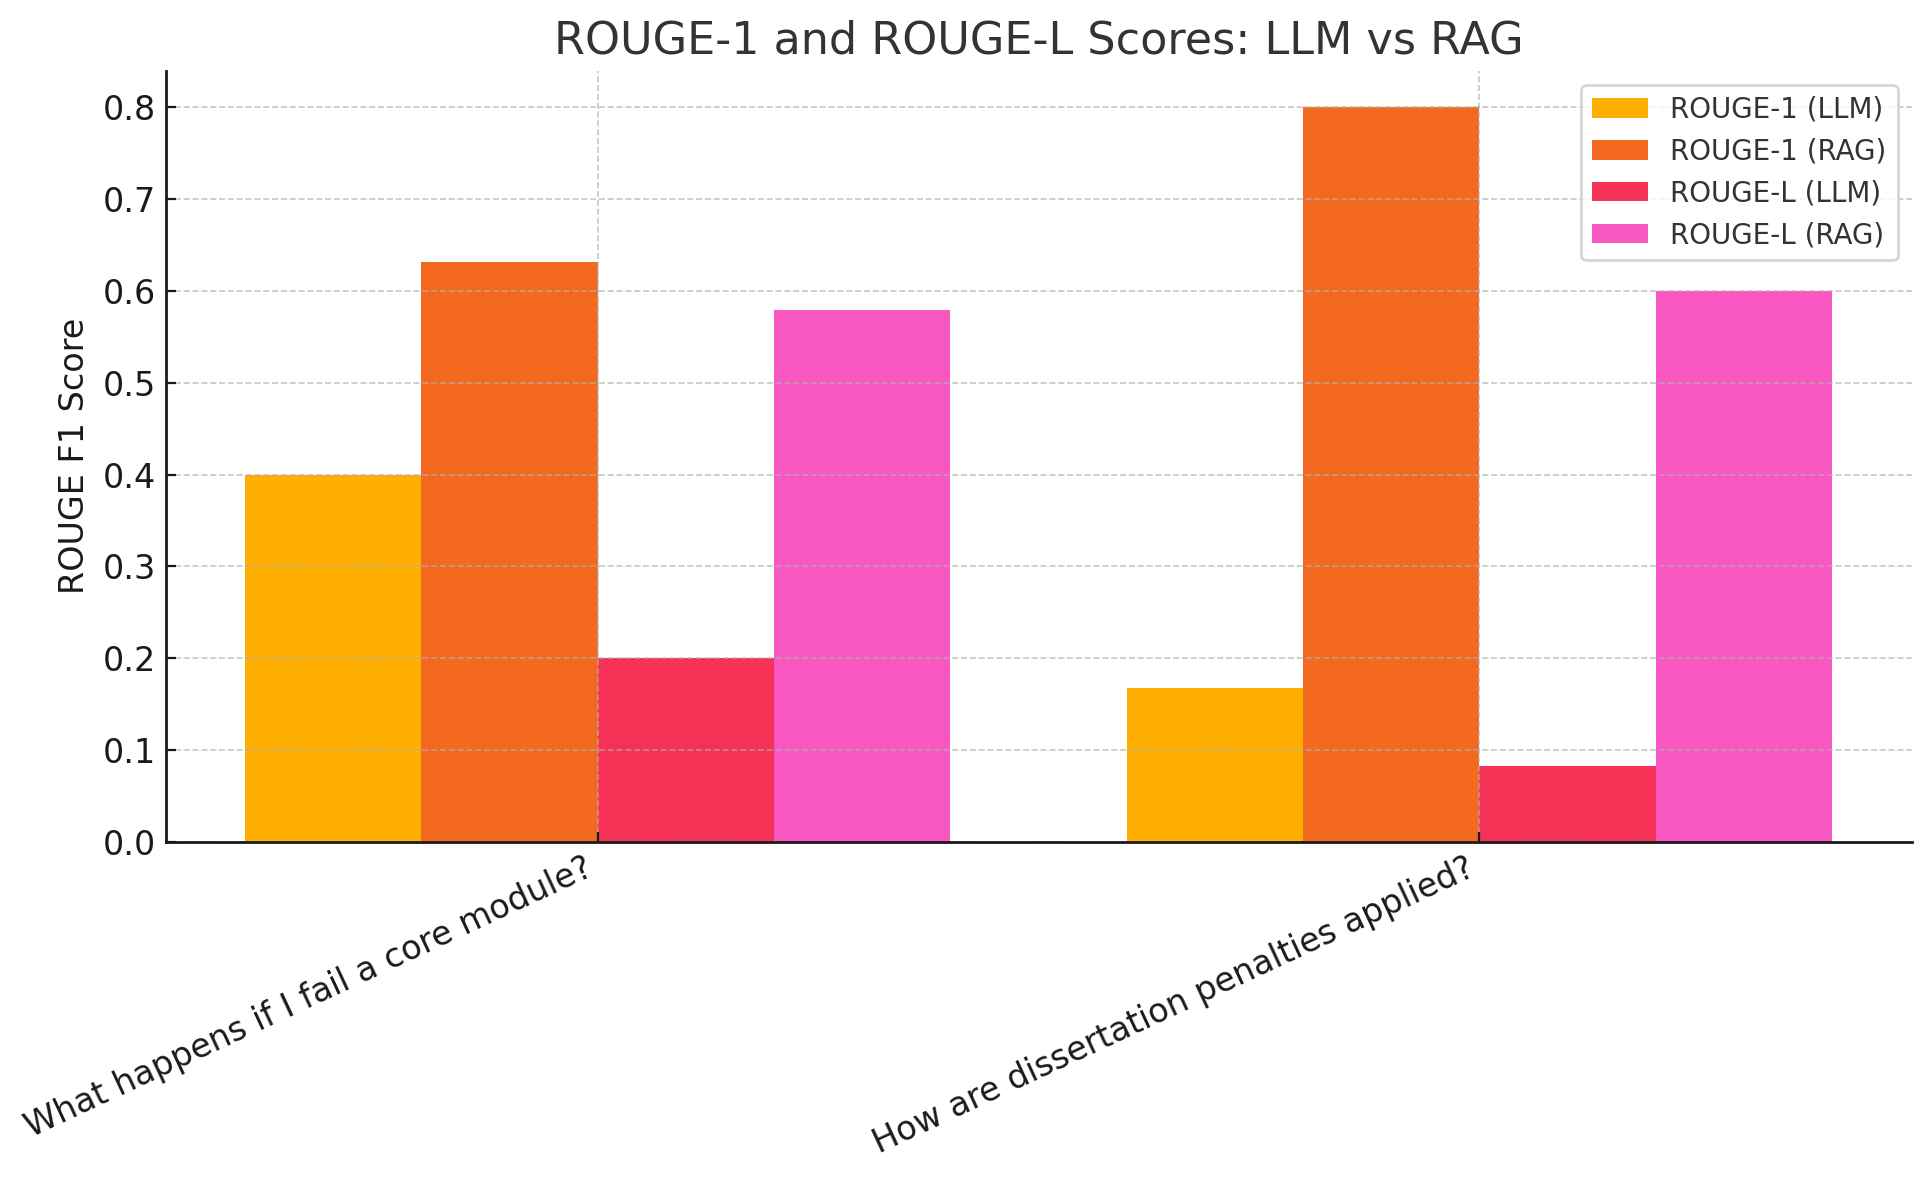

## 9.Future Improvements

The RAG system is helpful, but it could be improved further. **Hybrid retrieval**, which uses both keywords and vectors, is better at handling rule-based or rare terms. For more difficult questions, you can use **query rewriting, multi-hop retrieval** or queries that use LLMs.

The system could also be used for **several university handbooks**. If the textbook is updated annually with the latest versions, students from various institutions can utilise it as a valuable resource.

## 10.Conclusion

In conclusion, this project has shown that RAG helps students better understand university policies. With the help of the WBS Masters Handbook and LLaMA 2 7B, the system provides accurate, precise, and relevant answers through semantic embedding, re-ranking, and step-back prompting. Evaluating and comparing the RAG pipeline with standalone LLMs demonstrates its effectiveness. The project enhances learning for students at Warwick and also enables other universities to utilise it. When hybrid retrieval and regular handbook updates are added, the system will become a reliable resource for students.

## References

1. Asai, A., Hashimoto, K., Hajishirzi, H., Socher, R. and Xiong, C., 2020. Learning to retrieve reasoning paths over Wikipedia graph for question answering. arXiv preprint arXiv:2005.00782. Available at: https://arxiv.org/abs/2005.00782

2. Guu, K., Wang, K., Vilnis, L., Polosukhin, I. and Le, Q., 2023. HyDE: Enhancing retrieval with hypothetical documents for open-domain question answering. arXiv preprint arXiv:2212.10496. Available at: https://arxiv.org/abs/2212.10496

3. Izacard, G. and Grave, E., 2021. Leveraging passage retrieval with generative models for open domain question answering. arXiv preprint arXiv:2007.01282. Available at: https://arxiv.org/abs/2007.01282

4. Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., Küttler, H., Lewis, M., Yih, W.T., Rocktäschel, T., Riedel, S. and Kiela, D., 2020. Retrieval-augmented generation for knowledge-intensive NLP tasks. arXiv preprint arXiv:2002.08909. Available at: https://arxiv.org/abs/2002.08909

5. ModelScope (BAAI), 2023. BAAI/bge-reranker-base. Hugging Face. Available at: https://huggingface.co/BAAI/bge-reranker-base